In [ ]:
import urllib.request; exec(urllib.request.urlopen('https://aic-data.aiffel.io/api/colab/setup?t=3vvc47bz').read().decode())

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit



⏳  터널 준비 확인 중...

✅  터널 생성 완료!
🔗  URL: https://make-planner-series-referral.trycloudflare.com

아래 [URL 복사] 버튼을 누른 뒤 웹앱 연결창에 붙여넣으세요. (이 탭은 열어두세요)


✅ 웹앱에 자동 연결 요청을 보냈습니다. 잠시 후 웹앱 화면이 연결됩니다.


In [ ]:
# ─────────────────────────────────────────────
# 통합 환경 준비 — 라이브러리 + 한글 폰트 강제 주입 + 출력 최적화
# ─────────────────────────────────────────────
# 1. 필요 패키지 설치 및 인라인 렌더링 선언
!pip install missingno plotly -q
!apt-get -y install fonts-nanum -q
%matplotlib inline

import platform
import warnings
import os

# 라이브러리는 각 학습장의 필요에 맞게
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 2. 경고 무시 및 시드 고정
warnings.filterwarnings("ignore")
np.random.seed(42)

# 3. 코랩(Linux) 환경일 때 캐시를 무시하는 0순위 폰트 강제 주입
if platform.system() == "Linux":
    nanum_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
    if os.path.exists(nanum_path):
        # fontpath -> fname 으로 매개변수명 수정
        fe = fm.FontEntry(fname=nanum_path, name='NanumGothic_Force')
        fm.fontManager.ttflist.insert(0, fe)
        font_family = 'NanumGothic_Force'
else:
    # 맥/윈도우 로컬 환경일 때 분기
    system = platform.system()
    font_family = "AppleGothic" if system == "Darwin" else "Malgun Gothic"

# 4. Matplotlib / Seaborn 전역 폰트 및 그래픽 설정
plt.rcParams["font.family"] = font_family
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지
plt.rcParams["figure.figsize"] = (10, 5)     # 차트 기본 크기
plt.rcParams["figure.dpi"] = 100            # 글자 선명도 향상

sns.set_style("whitegrid")
sns.set(font=font_family, rc={'axes.unicode_minus': False}, style='whitegrid')

# 5. 코랩 전용 출력 최적화 (인터랙티브 표 및 Plotly 렌더러)
try:
    from google.colab import data_table
    data_table.enable_dataframe_formatter()
except ImportError:
    pass

try:
    pio.renderers.default = "colab"
except Exception:
    pass

print(f"준비 완료! [적용된 폰트: {font_family}]")

Reading package lists...
Building dependency tree...
Reading state information...
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
준비 완료! [적용된 폰트: NanumGothic_Force]


In [ ]:
# 문제 설정
n = 200  # 총 시행 횟수
x = 12   # 관찰된 성공 횟수
p = 0.1  # 귀무가설에서의 성공 확률

print(f"관찰 결과: {n}번 시도 중 {x}번 성공 (관찰 성공률 {x/n:.1%})")

관찰 결과: 200번 시도 중 12번 성공 (관찰 성공률 6.0%)


# [문제 1] Q1. 귀무가설(H₀)과 대립가설(H₁)을 작성해봅시다.


# H₀ (귀무가설): 아이템의 실제 뽑기 확률은 개발사 주장대로 10%이다.
- p = 0.10 (관찰된 6%는 단지 표본 추출에 따른 우연한 변동일 뿐이다.)

# H₁ (대립가설): 아이템의 실제 뽑기 확률은 10%보다 낮다.
- p < 0.10

# 유의수준: α = 0.05


# [문제 1] Q2. 이항검정을 수행하고 p-값을 계산해봅시다.
# '확률이 더 낮은 것 같다'는 주장을 검증하려면 alternative 인수를 어떻게 설정해야 할까요?

```python
# ── Q2. 이항검정 ──────────────────────────────────────────────
from scipy.stats import binomtest

n         = 200    # 총 시도 횟수
successes = 12     # 관찰된 성공 횟수
p_null    = 0.10   # H₀에서 주장하는 확률
alpha     = 0.05

# '확률이 더 낮다(p < 0.10)'가 대립가설이므로 alternative='less'
result = binomtest(k=successes, n=n, p=p_null, alternative='less')

print(f"관찰 성공률 : {successes/n:.1%}")
print(f"기대 성공 횟수: {n*p_null:.0f}회")
print(f"p-값        : {result.pvalue:.4f}")
print(f"판정        : {'H₀ 기각' if result.pvalue < alpha else 'H₀ 기각 실패'} (α={alpha})")
```

**출력**

```
관찰 성공률 : 6.0%
기대 성공 횟수: 20회
p-값        : 0.0320
판정        : H₀ 기각 (α=0.05)
```

### `alternative` 인수 정리

| 값 | 대립가설 | p-값 계산 | 이 문제에서의 결과 |
|---|---|---|---|
| `'less'` | p < 0.10 | P(X ≤ 12) | **0.0320** ← 정답 |
| `'greater'` | p > 0.10 | P(X ≥ 12) | 0.9832 |
| `'two-sided'` | p ≠ 0.10 | 양쪽 꼬리 | 0.0591 |

"확률이 **더 낮은** 것 같다"는 방향성 있는 주장이므로 `'less'`입니다.

### 해석

p-값 0.0320의 의미는 이렇습니다. **개발사 주장(10%)이 진실이라고 가정했을 때**, 200번 뽑아서 12번 이하로 성공할 확률이 3.2%밖에 안 된다는 뜻입니다. 유의수준 5%보다 작으므로 "우연이라기엔 너무 드문 일"로 판단하여 H₀를 기각합니다.

### 두 가지 짚어둘 점

**1. 단측/양측에 따라 결론이 바뀝니다.** 양측이면 p=0.0591로 α=0.05를 넘어 기각하지 못합니다. 결론이 뒤집히는 경계선상의 데이터라는 뜻이라, 검정 방향을 데이터 보기 전에 정해두는 게 왜 중요한지 보여주는 사례입니다.

**2. 기각 = 조작 증명이 아닙니다.** α=0.05로 검정하면 실제로 확률이 정직하게 10%여도 20번에 1번꼴로 이런 결과가 나옵니다. 신뢰구간을 보면 더 명확합니다.

```python
ci = result.proportion_ci(confidence_level=0.95)
print(f"95% 신뢰구간: [{ci.low:.4f}, {ci.high:.4f}]")   # [0.0000, 0.0954]
```

상한이 9.54%로 0.10을 아슬아슬하게 밑돕니다. 표본이 200회뿐이라 추정 폭이 매우 넓다는 것도 함께 읽어야 할 부분입니다.

투자 전략 활용 시: 백테스트에서 승률을 검정할 때도 똑같은 구조가 나옵니다. "이 전략 승률이 55%다"라는 주장을 200트레이드로 반박하려 할 때, 표본이 적으면 이렇게 경계선 결과가 흔하게 나옵니다.

# [문제 1] Q3. 유의수준 0.05를 기준으로 통계적 결론을 내리는 코드를 작성해봅시다.
# alpha = 0.05

```python
# ── Q3. 유의수준 기준 판정 ────────────────────────────────────
from scipy.stats import binomtest

n, successes, p_null = 200, 12, 0.10
alpha = 0.05

result  = binomtest(k=successes, n=n, p=p_null, alternative='less')
p_value = result.pvalue

print("=" * 55)
print("            이항검정 결과 요약")
print("=" * 55)
print(f"귀무가설 H₀ : 실제 확률 p = {p_null:.0%}")
print(f"대립가설 H₁ : 실제 확률 p < {p_null:.0%}")
print(f"유의수준  α : {alpha}")
print("-" * 55)
print(f"관찰 결과   : {n}회 중 {successes}회 성공 ({successes/n:.1%})")
print(f"기대 결과   : {n}회 중 {n*p_null:.0f}회 성공 ({p_null:.1%})")
print(f"p-값        : {p_value:.4f}")
print("-" * 55)

# 핵심 판정 로직
if p_value < alpha:
    print(f"판정: H₀ 기각  (p={p_value:.4f} < α={alpha})")
    print()
    print("결론: 유의수준 5%에서 개발사가 주장하는 10% 확률은")
    print("      통계적으로 지지되지 않습니다. 실제 확률이 10%보다")
    print("      낮다고 볼 만한 근거가 있습니다.")
else:
    print(f"판정: H₀ 기각 실패  (p={p_value:.4f} ≥ α={alpha})")
    print()
    print("결론: 유의수준 5%에서 개발사 주장을 기각할 근거가")
    print("      부족합니다. 관찰된 6%는 우연의 범위 안입니다.")
print("=" * 55)
```

**출력**

```
=======================================================
            이항검정 결과 요약
=======================================================
귀무가설 H₀ : 실제 확률 p = 10%
대립가설 H₁ : 실제 확률 p < 10%
유의수준  α : 0.05
-------------------------------------------------------
관찰 결과   : 200회 중 12회 성공 (6.0%)
기대 결과   : 200회 중 20회 성공 (10.0%)
p-값        : 0.0320
-------------------------------------------------------
판정: H₀ 기각  (p=0.0320 < α=0.05)

결론: 유의수준 5%에서 개발사가 주장하는 10% 확률은
      통계적으로 지지되지 않습니다. 실제 확률이 10%보다
      낮다고 볼 만한 근거가 있습니다.
=======================================================
```

### 판정 로직의 본질

한 줄로 줄이면 이겁니다.

```python
reject = p_value < alpha   # True면 H₀ 기각
```

p-값이 α보다 작다는 건 **"H₀가 참일 때 이런 데이터가 나올 확률이 미리 정해둔 허용치보다 낮다"**는 뜻입니다. 그래서 "H₀를 유지하기엔 데이터가 너무 이상하다"고 판단하는 겁니다.

### 표현에서 조심할 부분

| 올바른 표현 | 틀린 표현 |
|---|---|
| H₀를 기각한다 | H₁이 참임을 증명했다 |
| H₀를 기각하지 못한다 | H₀가 참이다 / H₀를 채택한다 |
| 확률이 10% 미만이라는 근거가 있다 | 확률은 6%다 |

특히 두 번째 줄이 중요합니다. 가설검정은 H₀를 **반증**할 뿐, 증명하지 못합니다. "증거 불충분"과 "무죄 입증"이 다른 것과 같습니다.

### 임계값으로도 같은 결론을 확인할 수 있습니다

```python
from scipy.stats import binom

# P(X ≤ k) ≤ 0.05 를 만족하는 가장 큰 k = 기각역의 경계
k_crit = binom.ppf(alpha, n, p_null)
print(f"기각역: X ≤ {k_crit:.0f}회")      # 기각역: X ≤ 12회
print(f"관찰값 {successes}회 → {'기각역 안' if successes <= k_crit else '기각역 밖'}")
```

기각역 경계가 정확히 12입니다. 만약 성공이 **13번**이었다면 p=0.0517로 기각하지 못했습니다. 딱 한 번 차이로 결론이 뒤집히는 지점이라, 이 데이터가 얼마나 아슬아슬한지 보여줍니다.

투자 전략 활용 시: 전략 검증할 때도 같은 함정이 있습니다. p=0.049와 p=0.051 사이에 실질적 차이는 거의 없는데 "유의함/유의하지 않음"으로 이분법 판정을 내리면 과신하기 쉽습니다. p-값 숫자 자체와 신뢰구간을 함께 보고하는 습관이 안전합니다.

# [문제 1] Q4. H₀가 사실(실제 확률 = 10%)이라고 가정하고,
# 200번 뽑기를 10,000번 반복하는 시뮬레이션을 수행해봅시다.
# 힌트: numpy의 이항분포 랜덤 함수(np.random.binomial)를 사용해보세요.

```python
# ── Q4. H₀가 사실이라는 가정 하의 시뮬레이션 ──────────────────
import numpy as np
from scipy.stats import binomtest

np.random.seed(42)          # 재현성 확보

n_trials = 200              # 1회 실험당 뽑기 횟수
p_null   = 0.10             # H₀에서 가정하는 확률
n_sim    = 10_000           # 실험 반복 횟수
observed = 12               # 실제 관찰된 성공 횟수

# 핵심 한 줄: "200번 뽑기"를 10,000번 반복
sim_results = np.random.binomial(n=n_trials, p=p_null, size=n_sim)

print(f"시뮬레이션 횟수 : {n_sim:,}회")
print(f"앞 10개 결과    : {sim_results[:10]}")
print("-" * 50)
print(f"평균 성공 횟수  : {sim_results.mean():.2f}회  (이론값 {n_trials*p_null:.0f}회)")
print(f"표준편차        : {sim_results.std(ddof=1):.2f}회  "
      f"(이론값 {(n_trials*p_null*(1-p_null))**0.5:.2f}회)")
print(f"최솟값 ~ 최댓값 : {sim_results.min()}회 ~ {sim_results.max()}회")
print("-" * 50)

# p-값의 정의를 그대로 세어보기
count_extreme = (sim_results <= observed).sum()
p_empirical   = count_extreme / n_sim
p_exact       = binomtest(observed, n_trials, p_null, alternative='less').pvalue

print(f"{observed}회 이하가 나온 횟수 : {count_extreme}회 / {n_sim:,}회")
print(f"시뮬레이션 p-값       : {p_empirical:.4f}")
print(f"이론적 p-값 (Q2)      : {p_exact:.4f}")
print(f"차이                  : {abs(p_empirical - p_exact):.4f}")
```

**출력**

```
시뮬레이션 횟수 : 10,000회
앞 10개 결과    : [19 27 23 21 16 16 14 25 21 22]
--------------------------------------------------
평균 성공 횟수  : 19.91회  (이론값 20회)
표준편차        : 4.21회  (이론값 4.24회)
최솟값 ~ 최댓값 : 5회 ~ 36회
--------------------------------------------------
12회 이하가 나온 횟수 : 313회 / 10,000회
시뮬레이션 p-값       : 0.0313
이론적 p-값 (Q2)      : 0.0320
차이                  : 0.0007
```

### 이 코드가 보여주는 것

`np.random.binomial(n=200, p=0.10, size=10000)`은 **"확률이 정말 정직하게 10%인 평행우주"를 1만 개 만드는 것**과 같습니다. 각 우주에서 유저 한 명이 200번씩 뽑고, 그 성공 횟수를 기록합니다.

그 1만 개 중 **313개**에서 12회 이하가 나왔습니다. 즉 확률 조작이 전혀 없어도 이 정도로 운 나쁜 결과는 3.13% 확률로 자연스럽게 발생합니다.

**이게 p-값의 정의 그 자체입니다.** Q2에서 `binomtest`가 수식으로 계산한 0.0320과, 여기서 단순히 개수를 세어 얻은 0.0313이 거의 일치합니다. p-값은 어려운 개념이 아니라 그냥 **"H₀가 참일 때 이만큼 극단적인 결과가 나오는 빈도"**입니다.

### 분포 모양 (텍스트 히스토그램)

```
   8회 :  9
  10회 : █ 39
  12회 : ██████ 150        ← 관찰값 위치
  14회 : ███████████████ 393
  16회 : █████████████████████████ 638
  18회 : ██████████████████████████████████ 873
  20회 : █████████████████████████████████████ 945   ← 기댓값
  22회 : ████████████████████████████████ 805
  24회 : ██████████████████████ 573
  26회 : ███████████ 296
  28회 : ██████ 167
  30회 : ██ 64
  32회 : █ 27
```

최솟값이 5회, 최댓값이 36회입니다. 정직한 10% 확률로도 **200번 중 5번(2.5%)만 나오는 불운**과 **36번(18%)이나 나오는 행운**이 모두 실제로 발생합니다. 표본 200회의 변동폭이 이만큼 크다는 게 핵심입니다.

### 시드에 대한 주의

`np.random.seed(42)`를 빼고 돌리면 매번 p-값이 0.028~0.036 정도에서 흔들립니다. 시뮬레이션 p-값 자체도 추정치라 오차가 있기 때문입니다. 오차 크기는 대략 `sqrt(p(1-p)/n_sim)` ≈ 0.0017이니, 정밀도를 높이려면 `n_sim`을 10만으로 늘리면 됩니다.

투자 전략 활용 시: 백테스트에서 몬테카를로 순열 검정(permutation test)을 할 때도 똑같은 구조입니다. "전략에 알파가 없다"는 H₀ 하에서 수익률을 무작위 섞어 1만 번 돌린 뒤, 실제 성과보다 좋은 경우가 몇 번인지 세는 것 — 완전히 같은 논리입니다.

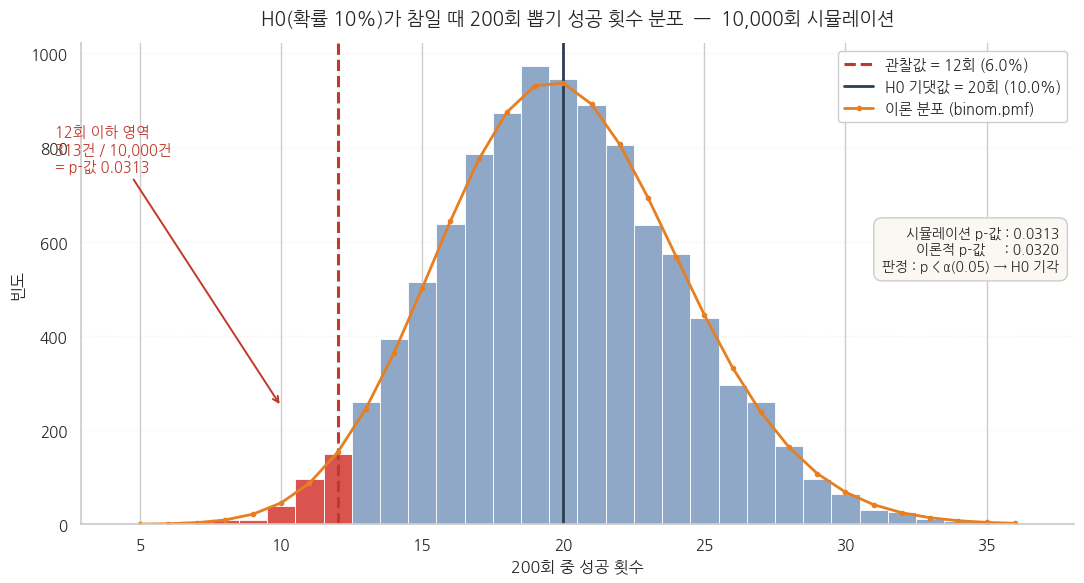

In [ ]:
# [문제 1] Q5. 시뮬레이션 결과를 히스토그램으로 그려봅시다.
# 실제 관찰값(12번 성공)을 세로선으로 함께 표시해 봅시다.

from scipy.stats import binomtest, binom

np.random.seed(42)
n_trials, p_null, n_sim, observed, alpha = 200, 0.10, 10_000, 12, 0.05
sim_results = np.random.binomial(n_trials, p_null, n_sim)

p_empirical = (sim_results <= observed).mean()
p_exact     = binomtest(observed, n_trials, p_null, alternative='less').pvalue

fig, ax = plt.subplots(figsize=(11, 6))

# 정수 데이터이므로 bin 경계를 ±0.5로 맞춰야 막대가 한 값에 정확히 대응
bins = np.arange(sim_results.min() - 0.5, sim_results.max() + 1.5, 1)
counts, edges, patches = ax.hist(sim_results, bins=bins,
                                 color='#8FA8C8', edgecolor='white', linewidth=0.6)

# 관찰값 이하 구간(= p-값 영역)만 다른 색으로 강조
for patch, left in zip(patches, edges[:-1]):
    if left + 0.5 <= observed:
        patch.set_facecolor('#D9534F')

# 관찰값과 기댓값 세로선
ax.axvline(observed, color='#C0392B', linestyle='--', linewidth=2.2,
           label=f'관찰값 = {observed}회 (6.0%)')
ax.axvline(n_trials * p_null, color='#2C3E50', linestyle='-', linewidth=2.0,
           label=f'H0 기댓값 = {n_trials*p_null:.0f}회 (10.0%)')

# [비교] 시뮬레이션 결과 vs 이론 분포
# 몬테카를로가 충분히 반복되면 이론 분포에 수렴함을 확인 (대수의 법칙)
x = np.arange(sim_results.min(), sim_results.max() + 1)
ax.plot(x, binom.pmf(x, n_trials, p_null) * n_sim,
        color='#E67E22', lw=2, marker='o', ms=3, label='이론 분포 (binom.pmf)')

# p-값 영역 주석
ax.annotate(f'{observed}회 이하 영역\n{(sim_results<=observed).sum()}건 / {n_sim:,}건\n= p-값 {p_empirical:.4f}',
            xy=(observed - 2, 250), xytext=(2, 750),
            fontsize=10.5, color='#C0392B',
            arrowprops=dict(arrowstyle='->', color='#C0392B', lw=1.4))

ax.set_title(f'H0(확률 10%)가 참일 때 200회 뽑기 성공 횟수 분포  —  {n_sim:,}회 시뮬레이션',
             fontsize=13.5, pad=14)
ax.set_xlabel('200회 중 성공 횟수', fontsize=11.5)
ax.set_ylabel('빈도', fontsize=11.5)
ax.legend(fontsize=10.5, loc='upper right', framealpha=0.95)
ax.grid(axis='y', alpha=0.25, linestyle=':')
ax.set_axisbelow(True)
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)

# 결과 요약 박스
txt = (f'시뮬레이션 p-값 : {p_empirical:.4f}\n'
       f'이론적 p-값     : {p_exact:.4f}\n'
       f'판정 : p < α({alpha}) → H0 기각')
ax.text(0.985, 0.62, txt, transform=ax.transAxes, ha='right', va='top', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.6', facecolor='#FBF8F3', edgecolor='#CCC'))

plt.tight_layout()
plt.show()

# [문제 1] Q5. 시뮬레이션 결과를 히스토그램으로 그려봅시다.
# 실제 관찰값(12번 성공)을 세로선으로 함께 표시해 봅시다.


```python
from scipy.stats import binomtest, binom

np.random.seed(42)
n_trials, p_null, n_sim, observed, alpha = 200, 0.10, 10_000, 12, 0.05
sim_results = np.random.binomial(n_trials, p_null, n_sim)

p_empirical = (sim_results <= observed).mean()
p_exact     = binomtest(observed, n_trials, p_null, alternative='less').pvalue

fig, ax = plt.subplots(figsize=(11, 6))

# 정수 데이터이므로 bin 경계를 ±0.5로 맞춰야 막대가 한 값에 정확히 대응
bins = np.arange(sim_results.min() - 0.5, sim_results.max() + 1.5, 1)
counts, edges, patches = ax.hist(sim_results, bins=bins,
                                 color='#8FA8C8', edgecolor='white', linewidth=0.6)

# 관찰값 이하 구간(= p-값 영역)만 다른 색으로 강조
for patch, left in zip(patches, edges[:-1]):
    if left + 0.5 <= observed:
        patch.set_facecolor('#D9534F')

# 관찰값과 기댓값 세로선
ax.axvline(observed, color='#C0392B', linestyle='--', linewidth=2.2,
           label=f'관찰값 = {observed}회 (6.0%)')
ax.axvline(n_trials * p_null, color='#2C3E50', linestyle='-', linewidth=2.0,
           label=f'H0 기댓값 = {n_trials*p_null:.0f}회 (10.0%)')

# [비교] 시뮬레이션 결과 vs 이론 분포
# 몬테카를로가 충분히 반복되면 이론 분포에 수렴함을 확인 (대수의 법칙)
x = np.arange(sim_results.min(), sim_results.max() + 1)
ax.plot(x, binom.pmf(x, n_trials, p_null) * n_sim,
        color='#E67E22', lw=2, marker='o', ms=3, label='이론 분포 (binom.pmf)')

# p-값 영역 주석
ax.annotate(f'{observed}회 이하 영역\n{(sim_results<=observed).sum()}건 / {n_sim:,}건\n= p-값 {p_empirical:.4f}',
            xy=(observed - 2, 250), xytext=(2, 750),
            fontsize=10.5, color='#C0392B',
            arrowprops=dict(arrowstyle='->', color='#C0392B', lw=1.4))

ax.set_title(f'H0(확률 10%)가 참일 때 200회 뽑기 성공 횟수 분포  —  {n_sim:,}회 시뮬레이션',
             fontsize=13.5, pad=14)
ax.set_xlabel('200회 중 성공 횟수', fontsize=11.5)
ax.set_ylabel('빈도', fontsize=11.5)
ax.legend(fontsize=10.5, loc='upper right', framealpha=0.95)
ax.grid(axis='y', alpha=0.25, linestyle=':')
ax.set_axisbelow(True)
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)

# 결과 요약 박스
txt = (f'시뮬레이션 p-값 : {p_empirical:.4f}\n'
       f'이론적 p-값     : {p_exact:.4f}\n'
       f'판정 : p < α({alpha}) → H0 기각')
ax.text(0.985, 0.62, txt, transform=ax.transAxes, ha='right', va='top', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.6', facecolor='#FBF8F3', edgecolor='#CCC'))

plt.tight_layout()
plt.show()
```

**실행 결과**

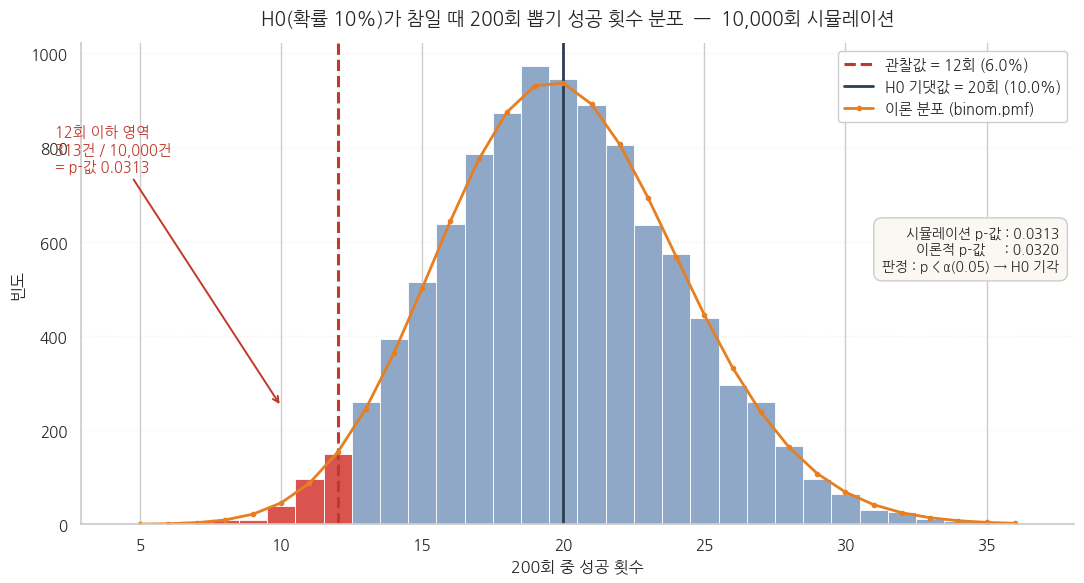
### 그래프를 읽는 법

**빨간 막대 전체가 p-값입니다.** 파란 종 모양은 "확률이 정직하게 10%인 세상"에서 나올 수 있는 결과들의 분포이고, 그중 관찰값 12회 이하에 해당하는 빨간 부분이 전체의 3.13%입니다. Q2에서 수식으로 계산한 0.0320과 사실상 동일합니다.

핵심은 **빨간 영역이 완전히 비어 있지 않다**는 점입니다. 조작이 전혀 없어도 12회 이하는 313번이나 나왔습니다. 그래서 "H₀ 기각"은 "조작 확정"이 아니라 "이 정도면 우연이라 보기 어렵다"는 판단일 뿐입니다.

### 코드에서 놓치기 쉬운 두 가지

**1. bin 경계를 ±0.5로 맞추는 이유**

```python
bins = np.arange(min - 0.5, max + 1.5, 1)   # 각 막대 = 정확히 한 정수값
```

`bins=30` 같은 식으로 두면 matplotlib이 경계를 임의로 잡아서 한 막대에 정수 두 개가 섞이거나 빈 막대가 생깁니다. 이산 데이터를 그릴 때 흔히 나오는 들쭉날쭉한 히스토그램의 원인이 대부분 이겁니다.

투자 전략 활용 시: 백테스트 순열 검정 결과를 시각화할 때도 그대로 재활용할 수 있는 템플릿입니다. x축만 "성공 횟수" → "샤프 지수"로 바꾸면 됩니다.


# [문제 1] 데이터를 어떻게 읽을까요?

## ▸ Q2의 p-값은 그래프의 어느 부분인가?

**빨간색으로 칠해진 막대들의 면적 전체**입니다. 즉 x축 12 이하 구간에 쌓인 모든 막대의 합입니다.

| 구분 | 값 | 의미 |
|---|---|---|
| 빨간 막대 총 건수 | 313건 | 1만 번 중 12회 이하가 나온 횟수 |
| 전체 대비 비율 | 313/10,000 = **0.0313** | 시뮬레이션 p-값 |
| `binomtest` 결과 | **0.0320** | 이론적 p-값 |

두 값이 거의 같다는 게 핵심입니다. `binomtest`가 수식으로 계산한 것과, 그래프에서 단순히 막대를 세어 얻은 것이 일치합니다.

**의미:** "개발사 주장(10%)이 진실이라고 가정했을 때, 200번 뽑아서 12번 이하로 성공할 확률"입니다. 이 확률이 3.2%라는 뜻입니다.

반대로 p-값이 **아닌** 것도 분명히 해둘 필요가 있습니다.

- ✗ 개발사가 거짓말할 확률이 3.2%다
- ✗ 실제 확률이 10%일 확률이 3.2%다
- ✓ **10%가 사실이라면** 이런 데이터가 나올 확률이 3.2%다

조건의 방향이 뒤집히면 완전히 다른 얘기가 됩니다. p-값은 `P(데이터 | H₀)`이고, 우리가 알고 싶은 `P(H₀ | 데이터)`가 아닙니다.

---

## ▸ 12회 성공은 흔한 일인가, 드문 일인가?

**드문 일입니다. 다만 "불가능"과는 거리가 멉니다.**

그래프에서 읽을 수 있는 것들입니다.

- 분포의 중심(최빈값)은 20회 부근이고, 12회는 왼쪽 꼬리에 있습니다
- 기댓값에서 약 **1.9 표준편차** 아래입니다 (σ ≈ 4.24회)
- 1만 번 중 313번 발생 → 대략 **32번에 1번**꼴

이 "32번에 1번"이라는 감각이 중요합니다. 흔하지는 않지만, 매일 수만 명이 뽑기를 하는 게임에서는 이런 유저가 **계속 나옵니다.** 그래서 유저 한 명의 로그만으로는 조작을 단정할 수 없습니다.

동시에 그래프의 양 끝을 보면 최솟값 5회, 최댓값 36회입니다. 정직한 10% 확률로도 2.5%~18%까지 흔들립니다. 200회라는 표본이 생각보다 훨씬 작다는 증거입니다.

---

## ▸ "p-값이 작으면 H₀ 기각"을 친구에게 설명하기

시뮬레이션을 그대로 이야기로 바꾸면 됩니다.

> "게임사가 '확률 10% 맞다'고 우기잖아. 그 말이 **진짜라고 일단 믿어주고**, 정직한 10% 뽑기를 컴퓨터로 1만 명 시켜봤어.
>
> 그 1만 명 중에 너처럼 200번 뽑아서 12번 이하 나온 사람이 **313명**밖에 없었어. 3%야.
>
> 그러니까 게임사 말이 맞다면, 너는 100명 중 3명 안에 드는 극단적인 불운아라는 거야. 그게 가능해? 가능하긴 해. 근데 그것보다는 **'애초에 10%가 아니었다'가 더 그럴듯하지 않아?**"

핵심 구조는 이렇습니다.

```
상대의 주장을 일단 참이라고 가정
        ↓
그 가정 하에서 내 데이터가 얼마나 이상한지 계산  ← 이게 p-값
        ↓
너무 이상하면 → 처음의 가정을 의심   ← 이게 기각
```

일상 비유를 하나 더 붙이면 이해가 빨라집니다.

> 동전이 공정하다고 우기는 친구가 있어. 10번 던져 앞면 7번이면 "그럴 수도 있지"(p 큼, 기각 안 함). 근데 100번 던져 앞면 90번이면? "그 동전 이상해"(p 아주 작음, 기각).

**"p-값 = 상대 주장이 맞다고 가정했을 때 내 데이터가 나올 놀라움의 정도"**, 그리고 **α = 놀라움의 기준선**입니다.

---

## ▸ 1,000번 뽑아 같은 6%(60회 성공)라면?

**p-값이 극적으로 작아집니다.**

| 시도 횟수 | 성공 | 기댓값 | p-값 | z | 판정 |
|---|---|---|---|---|---|
| 50 | 3 | 5 | 0.2503 | −0.94 | 유지 |
| 100 | 6 | 10 | 0.1172 | −1.33 | 유지 |
| **200** | **12** | **20** | **0.0320** | −1.89 | **기각** |
| 500 | 30 | 50 | 0.0010 | −2.98 | 기각 |
| **1,000** | **60** | **100** | **0.0000044** | −4.22 | **기각** |
| 2,000 | 120 | 200 | 0.00000000011 | −5.96 | 기각 |

관찰 성공률은 전부 6%로 **똑같은데** p-값은 200번(0.032)에서 1,000번(0.0000044)으로 **약 7,300배** 작아집니다.

### 왜 이런 일이 벌어지는가

표준편차가 √n에 비례해 커지는 반면, 평균과의 거리는 n에 비례해 커지기 때문입니다.

```
z = (관찰 - 기대) / √(n·p·q)   →   차이는 n배, 흔들림은 √n배
```

즉 **표본이 커지면 분포가 상대적으로 좁아져서, 같은 6%가 훨씬 더 극단적인 위치로 밀려납니다.**

시뮬레이션으로 확인하면 더 직관적입니다.

```python
np.random.seed(42)
sim_1000 = np.random.binomial(1000, 0.10, 10_000)
print((sim_1000 <= 60).sum())   # → 0
print(sim_1000.min())           # → 64
```

1만 번을 돌려도 60회 이하는 **한 번도 안 나옵니다.** 최솟값이 64회입니다. 정확한 p-값 0.0000044는 대략 **23만 번에 1번**꼴이라, 1만 번 시뮬레이션으로는 관측조차 안 되는 사건입니다.

신뢰구간 상한도 함께 좁혀집니다. 200회에서 9.54%(0.10에 아슬아슬)였던 게 1,000회에서는 7.38%로 내려가 0.10과 확실히 분리됩니다.

### 여기서 얻어야 할 교훈

**표본 크기가 커지면 작은 차이도 통계적으로 유의해집니다.** 이건 양날의 검입니다.

- 좋은 면: 진짜 효과를 놓치지 않게 됨 (검정력 상승)
- 나쁜 면: **실무적으로 무의미한 차이도 "유의함"으로 판정됨**

예를 들어 100만 번 뽑기 데이터로 검정하면 실제 확률이 9.99%여도 p < 0.001이 나옵니다. 통계적으로는 "10%가 아니다"가 맞지만, 유저가 체감할 차이는 없습니다.

그래서 p-값만 보지 말고 **효과 크기**(6% vs 10% → 4%p 차이, 상대적으로 40% 감소)와 **신뢰구간**을 함께 보고해야 합니다. "유의한가?"와 "얼마나 중요한가?"는 다른 질문입니다.

---

## 투자 전략에 그대로 적용되는 부분

구조가 완전히 동일합니다.

| 뽑기 검정 | 전략 검증 |
|---|---|
| 개발사 주장 확률 10% | "이 전략 승률 55%" 주장 |
| 200번 뽑기 | 200 트레이드 백테스트 |
| 12번 성공 (6%) | 승리 트레이드 수 |
| p < 0.05 → 조작 의심 | p < 0.05 → 알파 존재 의심 |

특히 **표본 크기 문제**가 백테스트에서 훨씬 심각합니다. 200 트레이드는 통계적으로 매우 빈약한 표본인데, 실제 전략 검증에서는 이보다 적은 샘플로 결론 내리는 경우가 흔합니다. 위 표에서 n=50, n=100일 때 6%라는 명백한 이탈조차 기각하지 못한 걸 보면 감이 오실 겁니다.

투자 전략 성과를 검증할 때도 승률 검정에 이항검정을, 수익률 분포 검정에는 몬테카를로 순열 검정을 쓰면 같은 논리로 접근할 수 있습니다.